# Evaluation of the Model

In [1]:
import joblib
import pandas as pd
from pathlib import Path

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [2]:
processed_path = Path("../data/processed")

X_test = pd.read_csv(processed_path / "X_test.csv")

y_test = pd.read_csv(
    processed_path / "y_test.csv"
).squeeze()

print(X_test.shape)
print(y_test.shape)

(504160, 78)
(504160,)


In [ ]:
models_path = Path("../models")

decision_tree = joblib.load(
    models_path / "decision_tree.pkl"
)

random_forest = joblib.load(
    models_path / "random_forest.pkl"
)

logistic_regression = joblib.load(
    models_path / "logistic_regression.pkl"
)

print("Models loaded successfully!")

Models loaded successfully!


In [8]:
dt_pred = decision_tree.predict(X_test)

rf_pred = random_forest.predict(X_test)

lr_pred = logistic_regression.predict(X_test)

print("Predictions completed.")

Predictions completed.


In [10]:
def evaluate_model(name, y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print("=" * 50)
    print(name)
    print("=" * 50)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nClassification Report")

    print(classification_report(
        y_true,
        y_pred,
        zero_division=0
    ))

    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

In [12]:
results = []

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        dt_pred
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    )
)

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        lr_pred
    )
)

Decision Tree
Accuracy : 0.9981
Precision: 0.9981
Recall   : 0.9981
F1 Score : 0.9981

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    419012
           1       0.82      0.86      0.84       390
           2       1.00      1.00      1.00     25603
           3       0.99      0.99      0.99      2057
           4       1.00      1.00      1.00     34569
           5       0.98      0.99      0.99      1046
           6       0.99      0.99      0.99      1077
           7       1.00      1.00      1.00      1186
           8       1.00      0.50      0.67         2
           9       0.75      0.86      0.80         7
          10       0.99      0.98      0.99     18139
          11       1.00      1.00      1.00       644
          12       0.73      0.73      0.73       294
          13       1.00      0.75      0.86         4
          14       0.42      0.42      0.42       130

    accuracy             

In [13]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.998092,0.998100,0.998092,0.998095
1,Random Forest,0.996852,0.998219,0.996852,0.997380
2,Logistic Regression,0.978029,0.980496,0.978029,0.978142


In [14]:
results_path = Path("../results")

results_df.to_csv(
    results_path / "model_comparison.csv",
    index=False
)

print("Results saved successfully!")

Results saved successfully!


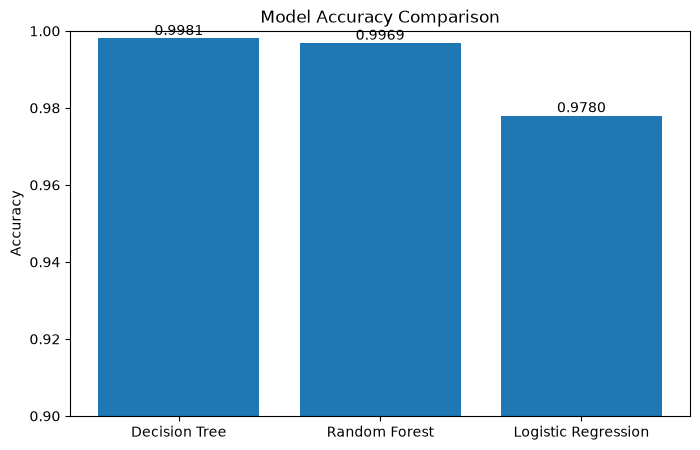

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

bars = plt.bar(results_df["Model"], results_df["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.9, 1.0)

# Add values on top of the bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.4f}",
        ha="center",
        va="bottom"
    )

plt.show()

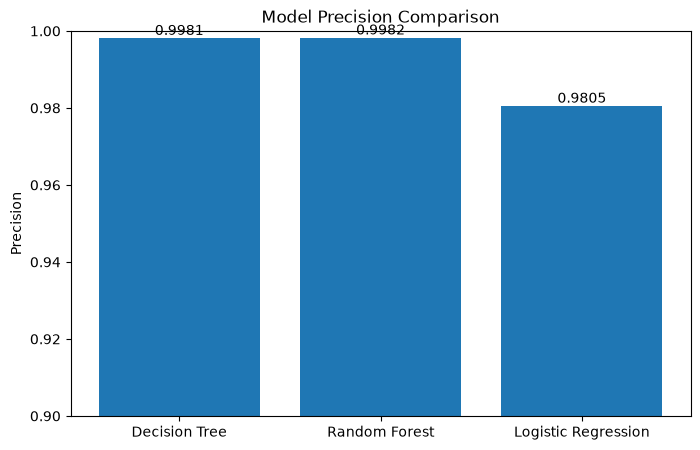

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

bars = plt.bar(results_df["Model"], results_df["Precision"])

plt.title("Model Precision Comparison")
plt.ylabel("Precision")
plt.ylim(0.9, 1.0)

# Add values on top of the bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.4f}",
        ha="center",
        va="bottom"
    )

plt.show()

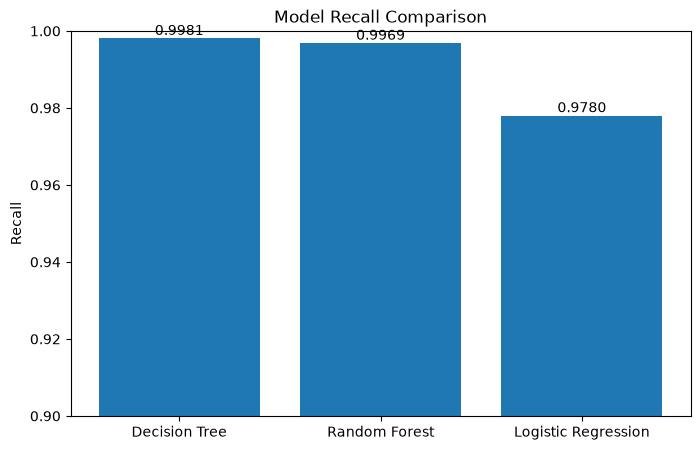

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

bars = plt.bar(results_df["Model"], results_df["Recall"])

plt.title("Model Recall Comparison")
plt.ylabel("Recall")
plt.ylim(0.9, 1.0)

# Add values on top of the bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.4f}",
        ha="center",
        va="bottom"
    )

plt.show()

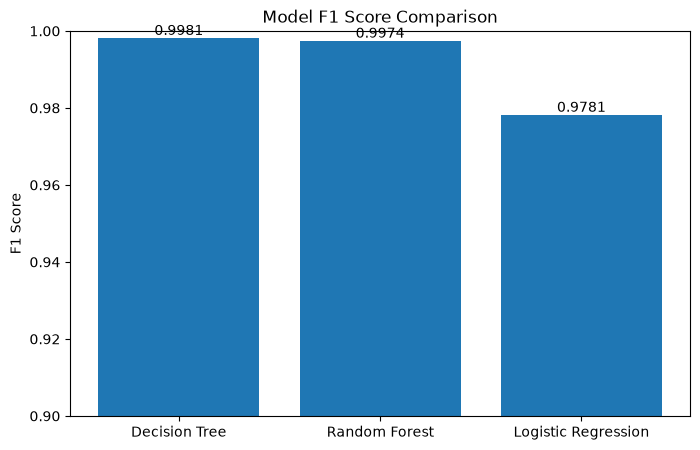

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

bars = plt.bar(results_df["Model"], results_df["F1 Score"])

plt.title("Model F1 Score Comparison")
plt.ylabel("F1 Score")
plt.ylim(0.9, 1.0)

# Add values on top of the bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.4f}",
        ha="center",
        va="bottom"
    )

plt.show()